#User Feature EDA

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
user_features = pd.read_csv("/content/drive/MyDrive/user_features.csv")

In [4]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,amount_only_flight_trips,amount_only_hotel_trips,amount_pauschal_trips,seats,hotel_revenue_w_discount,flight_revenue_w_discount,rooms,nights,checked_bags,cancellation,amount_unique_destinations,fav_hotel
0,94883,F,True,False,usa,kansas city,MCI,54,NaN,NaN,2.0,1.5,230.00,1487.260,1.50,1.0,0.5,0,2.0,NaN
1,101486,F,True,True,usa,tacoma,TCM,53,NaN,1.0,1.0,1.0,2199.00,189.910,1.50,4.0,0.0,0,1.0,NaN
2,101961,F,True,False,usa,boston,BOS,45,NaN,NaN,5.0,1.0,2429.00,1237.693,1.00,3.8,0.4,0,5.0,NaN
3,106907,F,True,True,usa,miami,TNT,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
4,118043,F,False,True,usa,los angeles,LAX,54,1.0,2.0,2.0,2.0,5616.45,5126.560,1.25,5.5,1.0,0,3.0,Fairmont
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,52,1.0,NaN,1.0,1.5,220.00,1597.182,2.00,1.0,0.0,0,2.0,NaN
5994,785186,F,True,True,usa,little rock,LIT,47,NaN,NaN,2.0,1.0,291.00,353.350,1.00,1.0,0.0,0,2.0,NaN
5995,792549,F,False,False,usa,kansas city,MCI,48,3.0,NaN,1.0,1.0,144.00,1039.170,1.00,4.0,0.5,0,4.0,NaN
5996,811077,F,True,True,usa,knoxville,TYS,47,NaN,NaN,1.0,1.0,852.00,579.790,1.00,6.0,0.0,0,1.0,NaN


In [5]:
user_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     5998 non-null   int64  
 1   gender                      5998 non-null   object 
 2   married                     5998 non-null   bool   
 3   has_children                5998 non-null   bool   
 4   home_country                5998 non-null   object 
 5   home_city                   5998 non-null   object 
 6   home_airport                5998 non-null   object 
 7   age                         5998 non-null   int64  
 8   amount_only_flight_trips    1389 non-null   float64
 9   amount_only_hotel_trips     1960 non-null   float64
 10  amount_pauschal_trips       4859 non-null   float64
 11  seats                       4855 non-null   float64
 12  hotel_revenue_w_discount    5336 non-null   float64
 13  flight_revenue_w_discount   4855 

##Preprocessing

In [6]:
user_features['amount_only_flight_trips'] = user_features['amount_only_flight_trips'].fillna(0)
user_features['amount_only_hotel_trips'] = user_features['amount_only_hotel_trips'].fillna(0)
user_features['amount_pauschal_trips'] = user_features['amount_pauschal_trips'].fillna(0)

In [7]:
user_features["amount_total_trips"] = user_features["amount_only_flight_trips"] + user_features["amount_only_hotel_trips"] + user_features["amount_pauschal_trips"]

In [8]:
user_features.isna().sum().sort_values(ascending=False)

,0
fav_hotel,5346
amount_unique_destinations,1143
flight_revenue_w_discount,1143
seats,1143
checked_bags,1143
rooms,662
hotel_revenue_w_discount,662
nights,662
home_country,0
user_id,0


In [9]:
user_features.shape

(5998, 21)

In [10]:
user_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     5998 non-null   int64  
 1   gender                      5998 non-null   object 
 2   married                     5998 non-null   bool   
 3   has_children                5998 non-null   bool   
 4   home_country                5998 non-null   object 
 5   home_city                   5998 non-null   object 
 6   home_airport                5998 non-null   object 
 7   age                         5998 non-null   int64  
 8   amount_only_flight_trips    5998 non-null   float64
 9   amount_only_hotel_trips     5998 non-null   float64
 10  amount_pauschal_trips       5998 non-null   float64
 11  seats                       4855 non-null   float64
 12  hotel_revenue_w_discount    5336 non-null   float64
 13  flight_revenue_w_discount   4855 

In [11]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'amount_only_flight_trips',
       'amount_only_hotel_trips', 'amount_pauschal_trips', 'seats',
       'hotel_revenue_w_discount', 'flight_revenue_w_discount', 'rooms',
       'nights', 'checked_bags', 'cancellation', 'amount_unique_destinations',
       'fav_hotel', 'amount_total_trips'],
      dtype='object')

In [12]:
user_features[[ "amount_only_flight_trips", "amount_only_hotel_trips", "amount_pauschal_trips", "amount_total_trips" ]].head()

,amount_only_flight_trips,amount_only_hotel_trips,amount_pauschal_trips,amount_total_trips
0,0.0,0.0,2.0,2.0
1,0.0,1.0,1.0,2.0
2,0.0,0.0,5.0,5.0
3,0.0,0.0,0.0,0.0
4,1.0,2.0,2.0,5.0


In [13]:
user_features["amount_unique_destinations"] = user_features["amount_unique_destinations"].fillna(0)

In [14]:
user_features[[
    "hotel_revenue_w_discount",
    "flight_revenue_w_discount"
]].isna().sum()

,0
hotel_revenue_w_discount,662
flight_revenue_w_discount,1143


In [15]:
user_features["hotel_revenue_w_discount"] = (user_features["hotel_revenue_w_discount"].fillna(0))

user_features["flight_revenue_w_discount"] = (user_features["flight_revenue_w_discount"].fillna(0))

In [16]:
user_features["total_revenue_w_discount"] = user_features["hotel_revenue_w_discount"]+user_features["flight_revenue_w_discount"]

In [17]:
user_features[["hotel_revenue_w_discount","flight_revenue_w_discount","total_revenue_w_discount" ]].isna().sum()

,0
hotel_revenue_w_discount,0
flight_revenue_w_discount,0
total_revenue_w_discount,0


In [18]:
user_features["total_revenue_w_discount"].describe()

,total_revenue_w_discount
count,5998.000000
mean,3151.753720
std,3520.636037
min,0.000000
25%,1054.000000
50%,2301.414500
75%,4206.615500
max,76618.165000


#EDA

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,amount_only_flight_trips,amount_only_hotel_trips,...,hotel_revenue_w_discount,flight_revenue_w_discount,rooms,nights,checked_bags,cancellation,amount_unique_destinations,fav_hotel,amount_total_trips,total_revenue_w_discount
0,94883,F,True,False,usa,kansas city,MCI,54,0.0,0.0,...,230.00,1487.260,1.50,1.0,0.5,0,2.0,NaN,2.0,1717.260
1,101486,F,True,True,usa,tacoma,TCM,53,0.0,1.0,...,2199.00,189.910,1.50,4.0,0.0,0,1.0,NaN,2.0,2388.910
2,101961,F,True,False,usa,boston,BOS,45,0.0,0.0,...,2429.00,1237.693,1.00,3.8,0.4,0,5.0,NaN,5.0,3666.693
3,106907,F,True,True,usa,miami,TNT,47,0.0,0.0,...,0.00,0.000,NaN,NaN,NaN,1,0.0,NaN,0.0,0.000
4,118043,F,False,True,usa,los angeles,LAX,54,1.0,2.0,...,5616.45,5126.560,1.25,5.5,1.0,0,3.0,Fairmont,5.0,10743.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,52,1.0,0.0,...,220.00,1597.182,2.00,1.0,0.0,0,2.0,NaN,2.0,1817.182
5994,785186,F,True,True,usa,little rock,LIT,47,0.0,0.0,...,291.00,353.350,1.00,1.0,0.0,0,2.0,NaN,2.0,644.350
5995,792549,F,False,False,usa,kansas city,MCI,48,3.0,0.0,...,144.00,1039.170,1.00,4.0,0.5,0,4.0,NaN,4.0,1183.170
5996,811077,F,True,True,usa,knoxville,TYS,47,0.0,0.0,...,852.00,579.790,1.00,6.0,0.0,0,1.0,NaN,1.0,1431.790


In [21]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'amount_only_flight_trips',
       'amount_only_hotel_trips', 'amount_pauschal_trips', 'seats',
       'hotel_revenue_w_discount', 'flight_revenue_w_discount', 'rooms',
       'nights', 'checked_bags', 'cancellation', 'amount_unique_destinations',
       'fav_hotel', 'amount_total_trips', 'total_revenue_w_discount'],
      dtype='object')

##Building the groups

###Business trips

In [22]:
business_group = user_features[(user_features["nights"]<=2) & (user_features["checked_bags"] <= 0.5)
 & (~user_features["cancellation"]) & (user_features["amount_total_trips"] >= 3) & (user_features["seats"]<1.3)]

In [23]:
business_group.shape

(258, 22)

In [24]:
len(business_group) / len(user_features)

0.043014338112704234

Die Business-Traveller-Gruppe umfasst 258 Nutzer (4,5 % aller Nutzer). Diese Kunden zeichnen sich durch häufige, kurze Reisen mit wenig Gepäck, wenigen Stornierungen und meist Einzelbuchungen aus. Das Profil entspricht typischen Geschäftsreisenden.

In [25]:
business_group[["amount_total_trips", "nights", "checked_bags", "seats", "total_revenue_w_discount"]].describe()

,amount_total_trips,nights,checked_bags,seats,total_revenue_w_discount
count,258.000000,258.000000,258.000000,258.000000,258.000000
mean,3.782946,1.650000,0.304457,1.049806,2674.213211
std,0.827177,0.341720,0.171451,0.096653,1472.584952
min,3.000000,1.000000,0.000000,1.000000,769.536000
25%,3.000000,1.333333,0.250000,1.000000,1783.010000
50%,4.000000,1.666667,0.333333,1.000000,2297.720000
75%,4.000000,2.000000,0.500000,1.000000,3244.872500
max,6.000000,2.000000,0.500000,1.250000,13508.040000


In [26]:
user_features[["amount_total_trips","nights","checked_bags", "seats", "total_revenue_w_discount"]].describe()

,amount_total_trips,nights,checked_bags,seats,total_revenue_w_discount
count,5998.000000,5336.000000,4855.000000,4855.000000,5998.000000
mean,2.582361,3.817979,0.579303,1.185156,3151.753720
std,1.533290,2.801782,0.457929,0.367670,3520.636037
min,0.000000,1.000000,0.000000,1.000000,0.000000
25%,1.000000,2.000000,0.250000,1.000000,1054.000000
50%,3.000000,3.000000,0.500000,1.000000,2301.414500
75%,4.000000,5.000000,1.000000,1.250000,4206.615500
max,8.000000,30.000000,5.000000,6.000000,76618.165000


In [27]:
user_features["segment"] = "Other"
user_features.loc[user_features["user_id"].isin(business_group["user_id"]), "segment"] = "Business"

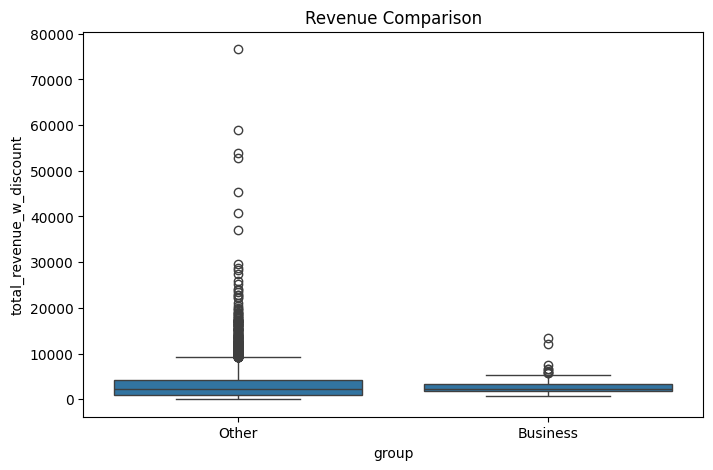

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

comparison = user_features.copy()
comparison["group"] = "Other"

comparison.loc[
    comparison["user_id"].isin(business_group["user_id"]),
    "group"
] = "Business"

plt.figure(figsize=(8,5))
sns.boxplot(
    data=comparison,
    x="group",
    y="total_revenue_w_discount"
)

plt.title("Revenue Comparison")
plt.show()

In [29]:
comparison.groupby("group")["total_revenue_w_discount"].agg(["count","mean","median","std","max"])

,count,mean,median,std,max
group,,,,,
Business,258,2674.213211,2297.72,1472.584952,13508.040
Other,5740,3173.218084,2302.88,3583.891127,76618.165


Business-Reisende buchen häufiger kurze Reisen mit wenig Gepäck, erzielen jedoch keinen wesentlich höheren Umsatz als andere Nutzergruppen.

In [30]:
user_features["revenue_per_trip"] = (user_features["total_revenue_w_discount"] / user_features["amount_total_trips"])

In [31]:
"revenue_per_trip" in comparison.columns

False

In [32]:
comparison = user_features.copy()

comparison["group"] = "Other"

comparison.loc[
    comparison["user_id"].isin(business_group["user_id"]),
    "group"
] = "Business"

<Axes: xlabel='group', ylabel='revenue_per_trip'>

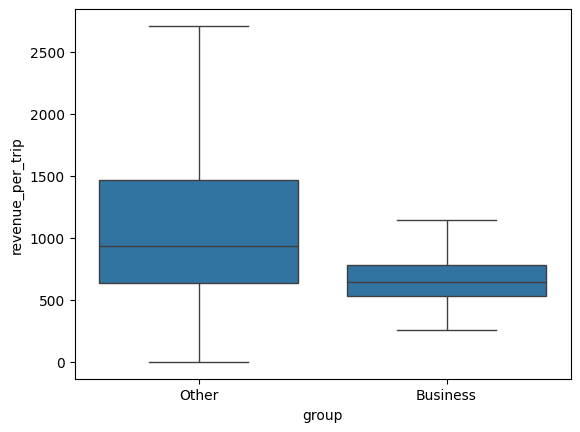

In [33]:
sns.boxplot( data=comparison,
    x="group",
    y="revenue_per_trip",
    showfliers=False)

Business Nutzer:

- häufig reisen
- kurze Aufenthalte haben
- wenig Gepäck mitnehmen

aber sie sind nicht die umsatzstärksten Reisenden pro Trip. Der Plot deutet eher darauf hin - Business-Reisende buchen häufiger, aber günstiger.

In [34]:
comparison.groupby("group")["revenue_per_trip"].agg( ["count", "mean", "median", "std"]).round(2)

,count,mean,median,std
group,,,,
Business,258,697.54,642.13,317.80
Other,5184,1283.92,936.48,1371.78


Business-Reisende unternehmen häufiger Reisen, geben jedoch pro Reise weniger Geld aus als andere Nutzer.

In [35]:
comparison.groupby("group")[["amount_total_trips","nights","checked_bags","revenue_per_trip"]].mean().round(2)

,amount_total_trips,nights,checked_bags,revenue_per_trip
group,,,,
Business,3.78,1.65,0.30,697.54
Other,2.53,3.93,0.59,1283.92


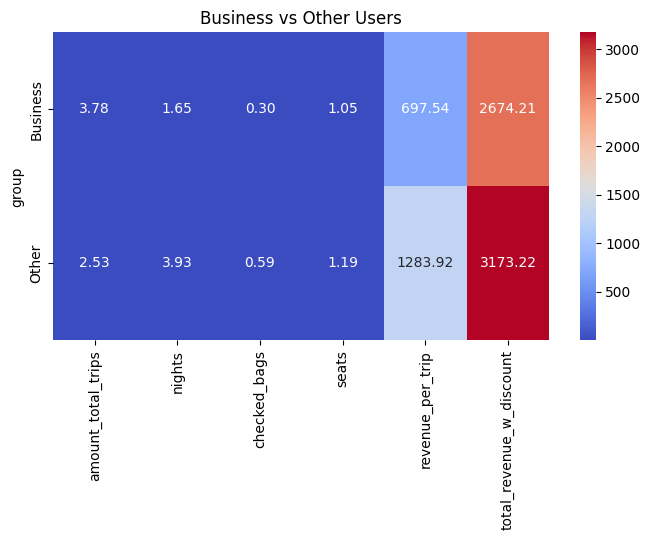

In [36]:
heatmap_data = comparison.groupby("group")[
    ["amount_total_trips",
     "nights",
     "checked_bags","seats",
     "revenue_per_trip",
    "total_revenue_w_discount"]
].mean()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Business vs Other Users")
plt.show()

Die Business-Gruppe zeichnet sich durch häufigere Reisen (3.78 vs. 2.53 Reisen), kürzere Aufenthalte (1.65 vs. 3.93 Nächte) und weniger Gepäck (0.30 vs. 0.59 Gepäckstücke) aus und reist überwiegend allein. Trotz der höheren Reisehäufigkeit liegt der durchschnittliche Umsatz pro Reise mit 698 USD deutlich unter dem der übrigen Nutzer (1.284 USD) sowie einen etwas niedrigeren Gesamtumsatz pro Nutzer (2.674 USD gegenüber 3.173 USD). Dies deutet darauf hin, dass Geschäftsreisende eher kurze und kosteneffiziente Reisen buchen, während Freizeitreisende längere und umsatzstärkere Aufenthalte haben.

Gesamteinnahmen pro Nutzer vergleichen

In [37]:
comparison.groupby("group")["total_revenue_w_discount"].mean()

,total_revenue_w_discount
group,
Business,2674.213211
Other,3173.218084


Auch der durchschnittliche Gesamtumsatz pro Nutzer fällt geringer aus (2.674 USD vs. 3.173 USD). Die Business-Gruppe repräsentiert daher eher häufig reisende, kostenbewusste Kunden als die umsatzstärksten Nutzer der Plattform.

In [38]:
comparison.groupby("group")["amount_total_trips"].sum()

,amount_total_trips
group,
Business,976.0
Other,14513.0


Die identifizierte Business-Gruppe umfasst lediglich 4.5 % der Nutzer, generiert jedoch 6.3 % aller Reisen.

In [39]:
features = [
    "amount_total_trips",
    "nights",
    "checked_bags",
    "revenue_per_trip"
]

In [40]:
summary = comparison.groupby("group")[
    ["amount_total_trips",
     "nights",
     "checked_bags",
     "revenue_per_trip",
     "total_revenue_w_discount"]
].mean()

summary

,amount_total_trips,nights,checked_bags,revenue_per_trip,total_revenue_w_discount
group,,,,,
Business,3.782946,1.650000,0.304457,697.540235,2674.213211
Other,2.528397,3.928128,0.594728,1283.922107,3173.218084


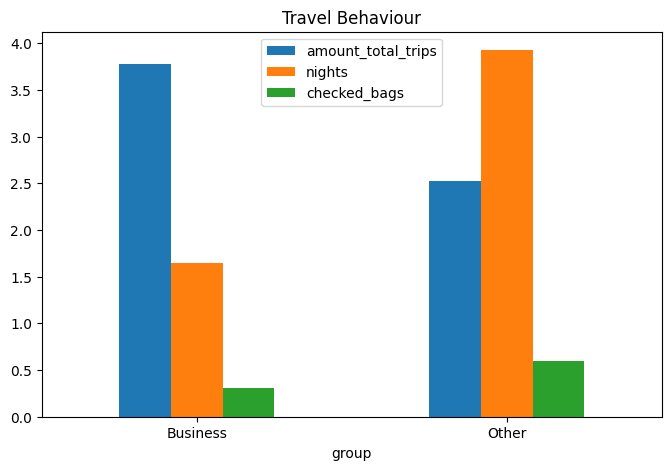

In [41]:
comparison.groupby("group")[
    ["amount_total_trips","nights","checked_bags"]
].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Travel Behaviour")
plt.xticks(rotation=0)
plt.show()

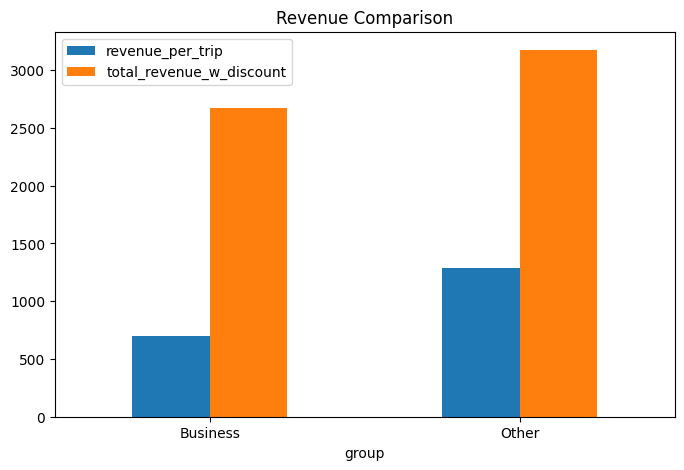

In [42]:
comparison.groupby("group")[
    ["revenue_per_trip","total_revenue_w_discount"]
].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue Comparison")
plt.xticks(rotation=0)
plt.show()

In [44]:
user_features = user_features[ ~user_features["user_id"].isin(business_group["user_id"])].copy()

#Geschäftliche Bedeutung
#Aufgrund der hohen Aktivität stellen diese Nutzer ein attraktives Segment für Kundenbindungsprogramme, Premium-Services (Priority Boarding, Fast Track Security, Lounge-Zugang, flexible Umbuchungen) und Geschäftsreiseangebote (Firmenrabatte, Corporate Accounts,Geschäftsreise-Pakete) dar. Obwohl der Umsatz pro Reise geringer ausfällt als bei anderen Nutzern, bietet die Gruppe Potenzial für langfristige Kundenbindung und wiederkehrende Umsätze.

##Short trip

In [45]:
short_trip_group = user_features[(user_features["nights"]<=2) &
 (user_features["checked_bags"] <= 0.5) & (~user_features["cancellation"]) & (user_features["amount_total_trips"] < 3)]

In [46]:
short_trip_group.shape

(430, 24)

In [47]:
len(short_trip_group) / len(user_features)

0.07491289198606271

- 430 Nutzer in der Short-Trip-Gruppe
- 7,5 % aller verbleibenden Nutzer

In [48]:
comparison = pd.concat([
    short_trip_group.assign(group="Short Trip"),
    user_features[
        ~user_features["user_id"].isin(short_trip_group["user_id"])
    ].assign(group="Other")])

In [49]:
comparison.groupby("group")[["amount_total_trips", "nights", "checked_bags", "seats", "total_revenue_w_discount"]].mean()

,amount_total_trips,nights,checked_bags,seats,total_revenue_w_discount
group,,,,,
Other,2.598117,4.157172,0.634861,1.194885,3316.853554
Short Trip,1.667442,1.452326,0.205814,1.172093,1399.487043


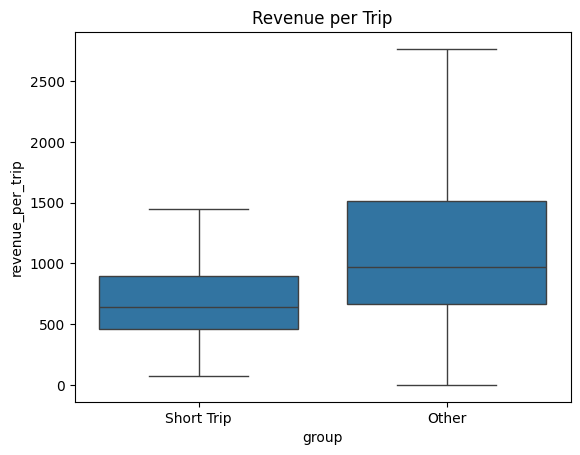

In [50]:
sns.boxplot(
    data=comparison,
    x="group",
    y="revenue_per_trip",
    showfliers=False
)

plt.title("Revenue per Trip")
plt.show()

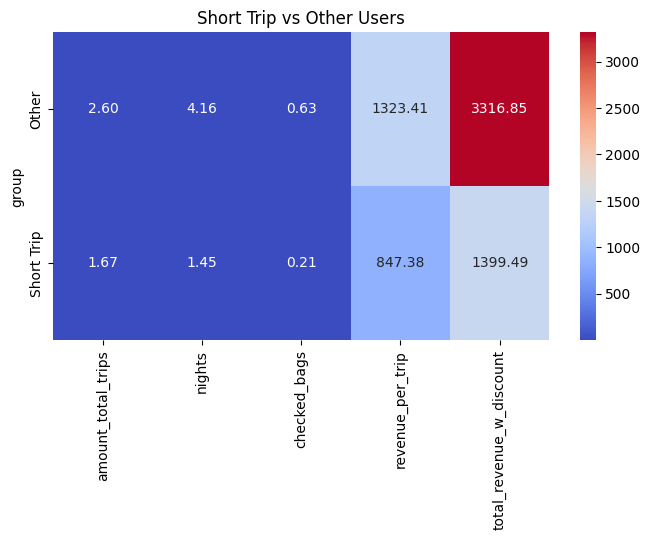

In [51]:
summary = comparison.groupby("group")[
    [
        "amount_total_trips",
        "nights",
        "checked_bags",
        "revenue_per_trip",
        "total_revenue_w_discount"
    ]
].mean()

plt.figure(figsize=(8,4))
sns.heatmap(
    summary,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Short Trip vs Other Users")
plt.show()

Die Short-Trip-Gruppe umfasst Nutzer mit kurzen Aufenthalten, wenig Gepäck und einer geringen Reisehäufigkeit. Im Vergleich zu den übrigen Nutzern verbringen sie durchschnittlich nur 1,45 Nächte am Reiseziel und buchen insgesamt weniger Reisen. Darüber hinaus generieren sie sowohl einen geringeren Umsatz pro Reise (847 USD gegenüber 1.323 USD) als auch einen deutlich niedrigeren Gesamtumsatz (1.399 USD gegenüber 3.317 USD). Die Gruppe stellt somit ein Segment von Gelegenheits- und Kurzreisenden dar, das für das Unternehmen einen vergleichsweise geringen wirtschaftlichen Wert besitzt.

#Geschäftliche Bedeutung
#Da die Short-Trip-Gruppe kurze Aufenthalte und einen vergleichsweise geringen Umsatz aufweist, bietet sie Potenzial für Cross-Selling-Maßnahmen. Beispielsweise könnten zusätzliche Hotelnächte, Hotel-Upgrades oder weitere Reiseleistungen wie Gepäckoptionen, Sitzplatzreservierungen oder Mietwagen angeboten werden, um den Umsatz pro Kunde zu steigern. Auch Last-Minute-Angebote oder Wochenend- und Kurzurlaubsaktionen kommen in Frage

In [52]:
comparison["group"].value_counts()

,count
group,
Other,5310
Short Trip,430


In [53]:
user_features = user_features[~user_features["user_id"].isin(short_trip_group["user_id"])].copy()

#Family group

In [54]:
family_traveler_group = user_features[user_features['has_children'] & (user_features["seats"]>1.5) & user_features["checked_bags"] > 0.5]

In [55]:
family_traveler_group.shape

(151, 24)

In [56]:
100 * len(family_traveler_group) / len(user_features)

2.8436911487758945

In [57]:
comparison["group"].value_counts()

,count
group,
Other,5310
Short Trip,430


In [58]:
comparison = pd.concat([ family_traveler_group.assign(group="Family"),
   user_features[ ~user_features["user_id"].isin(family_traveler_group["user_id"])].assign(group="Other")])

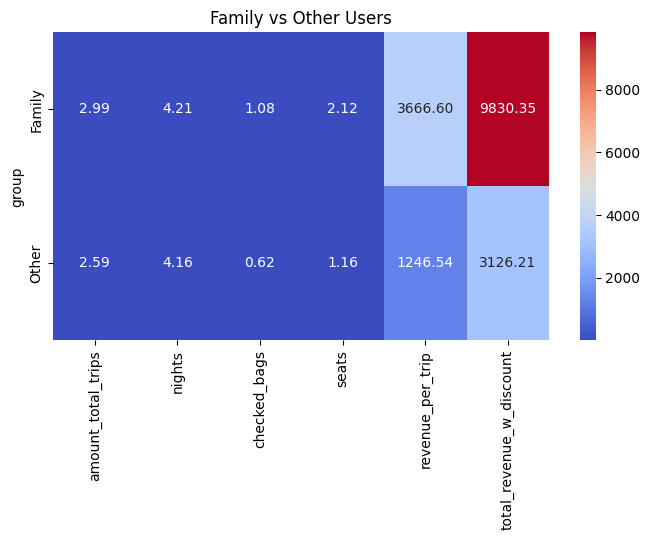

In [59]:
summary = comparison.groupby("group")[[
    "amount_total_trips",
    "nights",
    "checked_bags",
    "seats",
    "revenue_per_trip",
    "total_revenue_w_discount"
]].mean()

plt.figure(figsize=(8,4))
sns.heatmap(
    summary,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Family vs Other Users")
plt.show()

Die Family-Gruppe umfasst Nutzer mit Kindern, die durchschnittlich mehr Sitzplätze buchen und mehr Gepäck mitnehmen als andere Nutzer. Während die Aufenthaltsdauer nahezu identisch bleibt, generieren Familien einen deutlich höheren Umsatz. Der durchschnittliche Umsatz pro Reise beträgt 3.635 USD und liegt damit fast dreimal so hoch wie bei anderen Nutzern. Auch der Gesamtumsatz pro Nutzer fällt mit 9.718 USD mehr als dreimal höher aus. Die Family-Gruppe stellt somit das wirtschaftlich wertvollste Kundensegment dar.

In [60]:
comparison.groupby("group")[["seats", "checked_bags", "nights", "total_revenue_w_discount","amount_total_trips"]].mean()

,seats,checked_bags,nights,total_revenue_w_discount,amount_total_trips
group,,,,,
Family,2.119647,1.077815,4.211937,9830.354089,2.993377
Other,1.160114,0.618206,4.155371,3126.208356,2.586548


In [61]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,amount_only_flight_trips,amount_only_hotel_trips,...,rooms,nights,checked_bags,cancellation,amount_unique_destinations,fav_hotel,amount_total_trips,total_revenue_w_discount,segment,revenue_per_trip
1,101486,F,True,True,usa,tacoma,TCM,53,0.0,1.0,...,1.50,4.0,0.0,0,1.0,NaN,2.0,2388.910,Other,1194.4550
2,101961,F,True,False,usa,boston,BOS,45,0.0,0.0,...,1.00,3.8,0.4,0,5.0,NaN,5.0,3666.693,Other,733.3386
3,106907,F,True,True,usa,miami,TNT,47,0.0,0.0,...,NaN,NaN,NaN,1,0.0,NaN,0.0,0.000,Other,NaN
4,118043,F,False,True,usa,los angeles,LAX,54,1.0,2.0,...,1.25,5.5,1.0,0,3.0,Fairmont,5.0,10743.010,Other,2148.6020
5,149058,F,False,True,usa,birmingham,BHM,53,0.0,0.0,...,1.20,5.2,NaN,0,0.0,NaN,5.0,5579.000,Other,1115.8000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5990,770252,F,False,False,usa,oakland,OAK,27,0.0,0.0,...,NaN,NaN,NaN,1,0.0,NaN,0.0,0.000,Other,NaN
5991,774666,F,True,False,usa,minneapolis,MSP,47,1.0,0.0,...,1.00,5.0,1.5,0,2.0,NaN,2.0,1218.690,Other,609.3450
5995,792549,F,False,False,usa,kansas city,MCI,48,3.0,0.0,...,1.00,4.0,0.5,0,4.0,NaN,4.0,1183.170,Other,295.7925
5996,811077,F,True,True,usa,knoxville,TYS,47,0.0,0.0,...,1.00,6.0,0.0,0,1.0,NaN,1.0,1431.790,Other,1431.7900


In [62]:
comparison = pd.concat([
    family_traveler_group.assign(group="Family"),
    business_group.assign(group="Business")
])

comparison.groupby("group")[[
    "amount_total_trips",
    "nights",
    "checked_bags",
    "seats",
    "total_revenue_w_discount"
]].mean()

,amount_total_trips,nights,checked_bags,seats,total_revenue_w_discount
group,,,,,
Business,3.782946,1.650000,0.304457,1.049806,2674.213211
Family,2.993377,4.211937,1.077815,2.119647,9830.354089


In [63]:
family_traveler_group[[
    "seats",
    "nights",
    "checked_bags",
    "total_revenue_w_discount"
]].corr()

,seats,nights,checked_bags,total_revenue_w_discount
seats,1.000000,0.246086,0.801519,0.264402
nights,0.246086,1.000000,0.253395,0.116736
checked_bags,0.801519,0.253395,1.000000,0.312824
total_revenue_w_discount,0.264402,0.116736,0.312824,1.000000


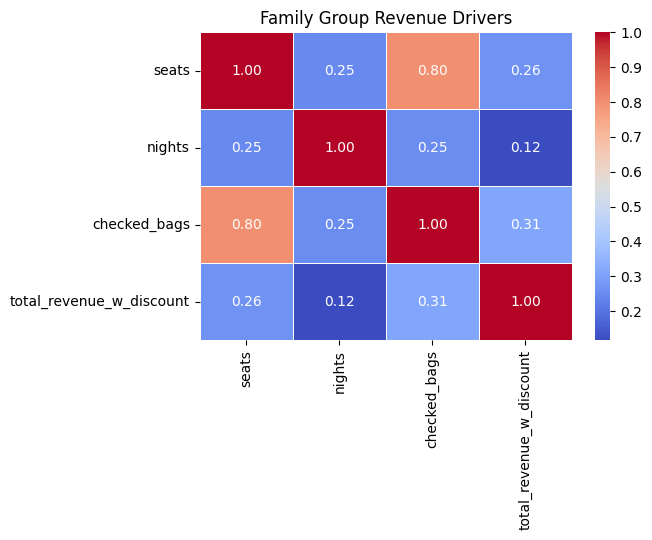

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

family_corr = family_traveler_group[[
    "seats",
    "nights",
    "checked_bags",
    "total_revenue_w_discount"
]].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    family_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Family Group Revenue Drivers")
plt.show()

Die Analyse der Familiengruppe zeigt, dass die Anzahl der Gepäckstücke (r = 0.32) den stärksten Zusammenhang mit dem Umsatz aufweist. Die Anzahl der gebuchten Sitzplätze zeigt ebenfalls einen positiven Zusammenhang (r = 0.26). Die Aufenthaltsdauer besitzt dagegen nur einen schwachen Einfluss auf den Umsatz (r = 0.12). Darüber hinaus besteht eine starke Korrelation zwischen der Anzahl der Sitzplätze und dem Gepäckvolumen (r = 0.79), was darauf hindeutet, dass größere Familien typischerweise mehr Gepäck mitführen. Somit wird der Umsatz in der Familiengruppe vor allem durch die Größe der Reisegruppe und das Reisevolumen beeinflusst.

##Lieblingsziele

In [65]:
flights = pd.read_csv("/content/drive/MyDrive/flights.csv")

In [66]:
flights.head()

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,363535-ae2567b185da4e3994607ce71f98a96b,CLT,phoenix,PHX,1,False,2023-01-13 15:00:00.000000,NaN,0,Alaska Airlines,33.535,-112.383,251.87
1,549482-f5e7931dd7b6460b90b89ea0aaabfc78,YVR,san diego,SAN,1,True,2023-07-25 11:00:00.000000,2023-07-31 11:00:00.000000,1,American Airlines,32.699,-117.215,369.26
2,585745-7f13ca3cb64441e08ba34a3020e7ff7b,LBB,new york,JFK,1,True,2023-07-24 07:00:00.000000,2023-07-29 07:00:00.000000,0,Allegiant Air,40.640,-73.779,407.51
3,596153-eb736cf7fe6f4aaf8c1638e399111ced,YKZ,calgary,YYC,1,True,2023-07-25 15:00:00.000000,2023-07-27 15:00:00.000000,1,WestJet,51.114,-114.020,449.58
4,636526-80cabddfe58c406d9ba90c77f85c66ff,LGA,los angeles,LAX,1,True,2023-07-23 13:00:00.000000,2023-07-26 13:00:00.000000,1,Air New Zealand,33.942,-118.408,691.85


In [67]:
sessions = pd.read_csv("/content/drive/MyDrive/sessions_cleaned.csv")

In [68]:
session_user = sessions[["trip_id", "user_id"]]

flights = flights.merge(
    session_user,
    on="trip_id",
    how="left"
)

In [69]:
family_destinations = flights[ flights["user_id"].isin(family_traveler_group["user_id"])]["destination"].value_counts().head(10)

family_destinations

,count
destination,
new york,63
los angeles,29
chicago,28
philadelphia,21
toronto,17
houston,17
phoenix,12
san antonio,11
san diego,10


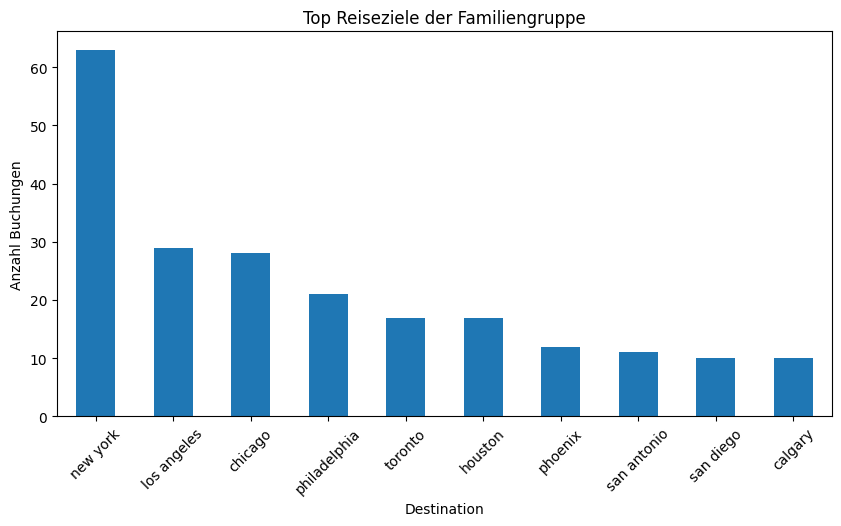

In [70]:
family_destinations.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Reiseziele der Familiengruppe")
plt.xlabel("Destination")
plt.ylabel("Anzahl Buchungen")
plt.xticks(rotation=45)
plt.show()

In [71]:
family_dest = flights[
    flights["user_id"].isin(family_traveler_group["user_id"])
]["destination"].value_counts(normalize=True)

other_dest = flights[
    ~flights["user_id"].isin(family_traveler_group["user_id"])
]["destination"].value_counts(normalize=True)

comparison = pd.concat(
    [family_dest, other_dest],
    axis=1
).fillna(0)

comparison.columns = ["Family", "Other"]

comparison.sort_values("Family", ascending=False).head(10)

,Family,Other
destination,,
new york,0.152542,0.139091
los angeles,0.070218,0.073751
chicago,0.067797,0.050019
philadelphia,0.050847,0.027938
toronto,0.041162,0.053699
houston,0.041162,0.040631
phoenix,0.029056,0.031018
san antonio,0.026634,0.027713
san diego,0.024213,0.024409


In [76]:
comparison["Difference"] = (comparison["Family"] - comparison["Other"])

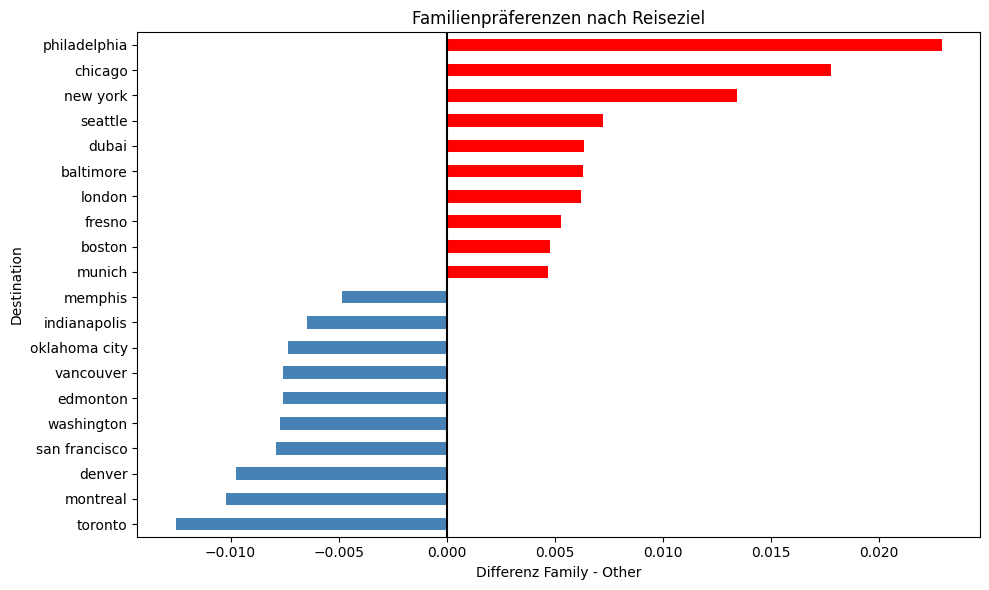

In [77]:
top_diff = pd.concat([
    comparison["Difference"].nlargest(10),
    comparison["Difference"].nsmallest(10)
]).sort_values()

colors = ["red" if x > 0 else "steelblue" for x in top_diff]

plt.figure(figsize=(10,6))

top_diff.plot(
    kind="barh",
    color=colors
)

plt.axvline(0, color="black")
plt.title("Familienpräferenzen nach Reiseziel")
plt.xlabel("Differenz Family - Other")
plt.ylabel("Destination")

plt.tight_layout()
plt.show()

Die Analyse der beliebtesten Reiseziele der Familiengruppe zeigt eine klare Präferenz für New York. Mit 64 Buchungen liegt New York deutlich vor Los Angeles (29) und Chicago (28). Die übrigen Destinationen werden deutlich seltener gebucht. Dies deutet darauf hin, dass Familienreisende vor allem große Städte mit vielfältigen Freizeit-, Kultur- und Unterhaltungsangeboten bevorzugen.

##Favorite Hotels

In [78]:
hotels = pd.read_csv("/content/drive/MyDrive/hotels_cleaned.csv")

In [79]:
session_user = sessions[["trip_id", "user_id"]]

hotels = hotels.merge(
    session_user,
    on="trip_id",
    how="left"
)

In [80]:
family_hotels = hotels[
    hotels["user_id"].isin(family_traveler_group["user_id"])
]["hotel_name"].value_counts().head(10)

family_hotels

,count
hotel_name,
Best Western,28
Rosewood,27
Hilton,26
NH Hotel,25
Banyan Tree,24
Four Seasons,24
Starwood,24
Extended Stay,23
Conrad,23


In [81]:
# Nur Familien
family_counts = hotels[
    hotels["user_id"].isin(family_traveler_group["user_id"])
]["hotel_name"].value_counts()

# Alle Buchungen
total_counts = hotels["hotel_name"].value_counts()

family_share = (
    family_counts / total_counts
).sort_values(ascending=False)

family_share.head(10)

,count
hotel_name,
Rosewood,0.036290
Best Western,0.035623
Hilton,0.033291
NH Hotel,0.032723
Starwood,0.032476
Banyan Tree,0.032389
Four Seasons,0.031662
Extended Stay,0.030749
Conrad,0.030585


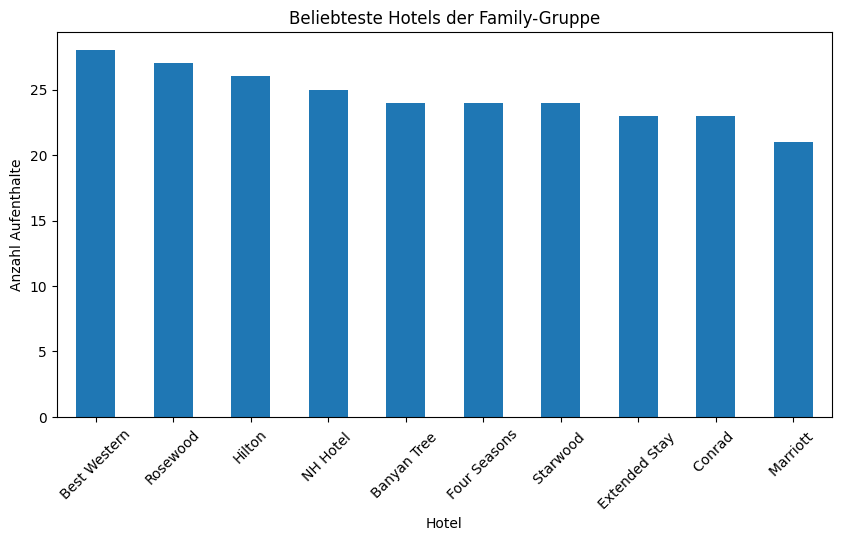

In [82]:
family_hotels.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Beliebteste Hotels der Family-Gruppe")
plt.xlabel("Hotel")
plt.ylabel("Anzahl Aufenthalte")
plt.xticks(rotation=45)
plt.show()

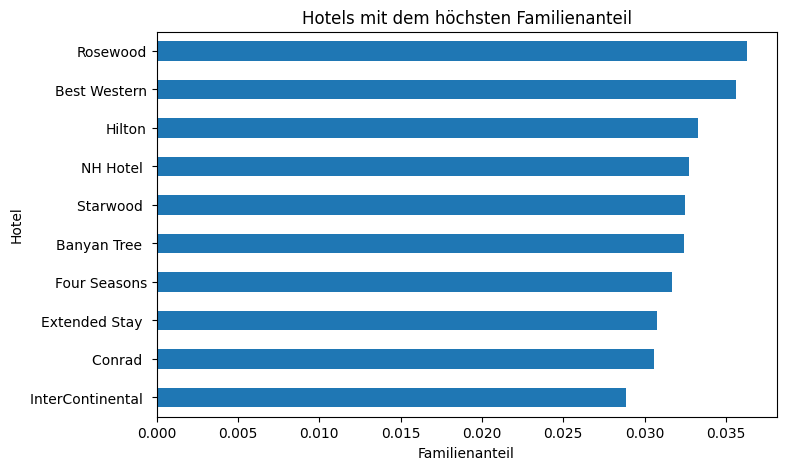

In [83]:
family_share.head(10).sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Hotels mit dem höchsten Familienanteil")
plt.xlabel("Familienanteil")
plt.ylabel("Hotel")
plt.show()

Die Analyse der Hotelpräferenzen zeigt, dass Familienreisende keine ausgeprägte Bindung an eine bestimmte Hotelkette aufweisen. Die höchsten Anteile entfallen auf Rosewood (3,63 %), Best Western (3,56 %) und NH Hotel (3,40 %), die Unterschiede zwischen den Hotels sind jedoch gering. Dies deutet darauf hin, dass Familien bei der Hotelauswahl flexibel sind und andere Faktoren wie Reiseziel, Preis oder Verfügbarkeit eine größere Rolle spielen könnten.

##Revenue pro Person

In [84]:
family_traveler_group["revenue_per_person"] = (
    family_traveler_group["total_revenue_w_discount"]
    / family_traveler_group["seats"]
)

family_traveler_group["revenue_per_person"].describe()

/tmp/ipykernel_7801/4078696898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  family_traveler_group["revenue_per_person"] = (


,revenue_per_person
count,151.000000
mean,4584.190923
std,4154.553326
min,142.880000
25%,2324.383500
50%,3628.852000
75%,5472.051111
max,26977.448000


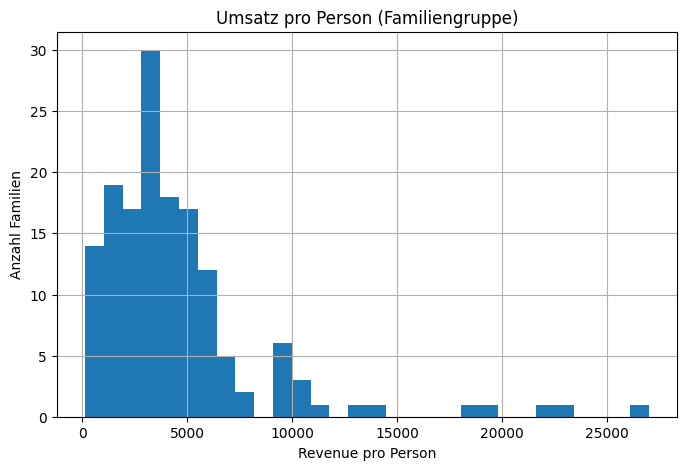

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

family_traveler_group["revenue_per_person"].hist(
    bins=30
)

plt.title("Umsatz pro Person (Familiengruppe)")
plt.xlabel("Revenue pro Person")
plt.ylabel("Anzahl Familien")

plt.show()

Der durchschnittliche Umsatz pro Person innerhalb der Familiengruppe beträgt 4.532 USD. Der Median liegt mit 3.557 USD deutlich darunter, was auf einige wenige sehr hochpreisige Reisen hinweist. Die Verteilung ist rechtsschief und enthält mehrere Ausreißer im oberen Bereich (mit Werten von über 15.000 USD pro Person.). Dies deutet darauf hin, dass ein Teil der Familiengruppe besonders hochwertige oder kostenintensive Reisen bucht.

##Luxus-Familien

In [86]:
family_traveler_group.sort_values(
    "revenue_per_person",
    ascending=False
)[[
    "user_id",
    "revenue_per_person",
    "total_revenue_w_discount",
    "seats",
    "nights",
    "checked_bags"
]].head(10)

,user_id,revenue_per_person,total_revenue_w_discount,seats,nights,checked_bags
1599,542918,26977.448000,53954.8960,2.000000,4.000000,1.500000
4275,533492,22594.260000,52719.9400,2.333333,2.000000,1.666667
2629,608820,21890.904286,76618.1650,3.500000,7.000000,3.500000
1382,535595,19647.610000,58942.8300,3.000000,6.000000,2.000000
1834,552573,18111.577600,45278.9440,2.500000,1.000000,2.000000
2836,651193,13577.596167,40732.7885,3.000000,3.500000,1.666667
1737,548222,12990.453000,25980.9060,2.000000,5.333333,1.333333
4461,540572,11041.888000,22083.7760,2.000000,4.333333,1.200000
5473,592598,10791.733333,19425.1200,1.800000,5.750000,1.800000
3581,513236,10622.562000,17704.2700,1.666667,4.000000,0.166667


Die Analyse der zehn umsatzstärksten Familien zeigt ein Premium-Segment mit sehr hoher Kaufkraft. Diese Kunden reisen meist mit 2–4 Personen, bleiben 4–7 Nächte und generieren einen deutlich höheren Umsatz als die durchschnittliche Familiengruppe. Sie stellen eine wichtige Zielgruppe für exklusive Familienangebote, Premium-Hotels und personalisierte Marketingmaßnahmen dar.

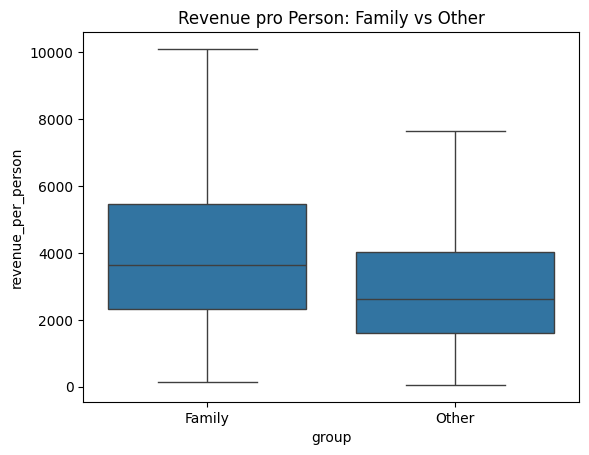

In [87]:
user_features["revenue_per_person"] = (
    user_features["total_revenue_w_discount"]
    / user_features["seats"]
)

comparison = pd.concat([
    family_traveler_group.assign(group="Family"),
    user_features[
        ~user_features["user_id"].isin(
            family_traveler_group["user_id"]
        )
    ].assign(group="Other")
])

sns.boxplot(
    data=comparison,
    x="group",
    y="revenue_per_person",
    showfliers=False
)

plt.title("Revenue pro Person: Family vs Other")
plt.show()

In [ ]:
comparison.groupby("group")["revenue_per_person"].agg(["mean", "median", "std"])

,mean,median,std
group,,,
Family,4532.314756,3556.642857,4130.691087
Other,3117.333326,2612.052500,2268.773326


Der Vergleich des Umsatzes pro Person zeigt deutliche Unterschiede zwischen Familienreisenden und anderen Nutzern. Familien generieren nicht nur aufgrund ihrer größeren Gruppengröße höhere Umsätze, sondern weisen auch einen höheren Umsatz pro Person auf. Der Median liegt bei Familien deutlich über dem der übrigen Nutzer. Darüber hinaus zeigt die Familiengruppe eine größere Streuung der Ausgaben, was auf unterschiedliche Reisebudgets innerhalb dieses Segments hindeutet. Insgesamt stellt die Familiengruppe ein besonders wertvolles Kundensegment dar.

##Anteil am Gesamtumsatz

In [88]:
family_revenue = family_traveler_group["total_revenue_w_discount"].sum()

total_revenue = user_features["total_revenue_w_discount"].sum()

family_revenue / total_revenue

np.float64(0.08428014820272026)

Obwohl Familienreisende nur rund 2,6 % aller Nutzer ausmachen, generieren sie etwa 8,5 % des Gesamtumsatzes. Damit trägt dieses Segment mehr als dreimal so stark zum Umsatz bei, wie es seinem Anteil an der Nutzerbasis entspricht. Familien stellen somit ein besonders wertvolles Kundensegment dar.

# Business-Empfehlungen

- Familienrabatte
- Familienzimmer
- Kinderermäßigungen
- Freizeit- und Freizeitpark-Pakete
- Hotel + Flug + Mietwagen Bundles
- Treueprogramme speziell für Familien

In [89]:
user_features = user_features[~user_features["user_id"].isin(family_traveler_group["user_id"])].copy()

##Cancellation

In [90]:
user_features["cancellation"].value_counts()

,count
cancellation,
0,4585
1,564
2,10


In [91]:
cancellation_group = user_features[user_features['cancellation']>0]

In [92]:
cancellation_group.shape

(574, 25)

In [93]:
len(cancellation_group) / len(user_features)

0.1112618724559023

In [94]:
comparison_cancellation = pd.concat([
    cancellation_group.assign(group="Cancelled"),
    user_features[
        ~user_features["user_id"].isin(cancellation_group["user_id"])
    ].assign(group="No Cancellation")
])

comparison.groupby("group")["total_revenue_w_discount"].mean()

,total_revenue_w_discount
group,
Family,9830.354089
Other,3126.208356


In [95]:
comparison.groupby("group")["amount_total_trips"].mean()

,amount_total_trips
group,
Family,2.993377
Other,2.586548


Nutzer mit mindestens einer Stornierung weisen im Durchschnitt einen geringeren Umsatz und eine niedrigere Reiseaktivität auf. Während Nutzer ohne Stornierungen durchschnittlich 3.256 USD Umsatz generieren und 2,67 Reisen buchen, erreichen Nutzer mit Stornierungen lediglich 2.093 USD Umsatz und 1,92 Reisen. Dies deutet darauf hin, dass stornierende Kunden insgesamt weniger wertvoll für das Unternehmen sind.

In [96]:
comparison_cancellation = pd.concat([
    cancellation_group.assign(group="Cancellation"),

    user_features[
        ~user_features["user_id"].isin(cancellation_group["user_id"])
    ].assign(group="Other")
])

In [97]:
comparison_cancellation["group"].value_counts()

,count
group,
Other,4585
Cancellation,574


In [98]:
# Umsatz pro Reise
comparison["revenue_per_trip"] = (
    comparison["total_revenue_w_discount"]
    / comparison["amount_total_trips"]
)

comparison.groupby("group")["revenue_per_trip"].mean()

,revenue_per_trip
group,
Family,3666.603186
Other,1246.539241


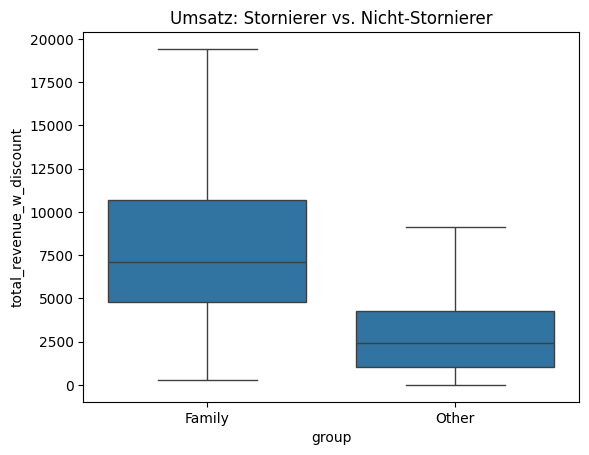

In [99]:
sns.boxplot(
    data=comparison,
    x="group",
    y="total_revenue_w_discount",
    showfliers=False
)

plt.title("Umsatz: Stornierer vs. Nicht-Stornierer")
plt.show()

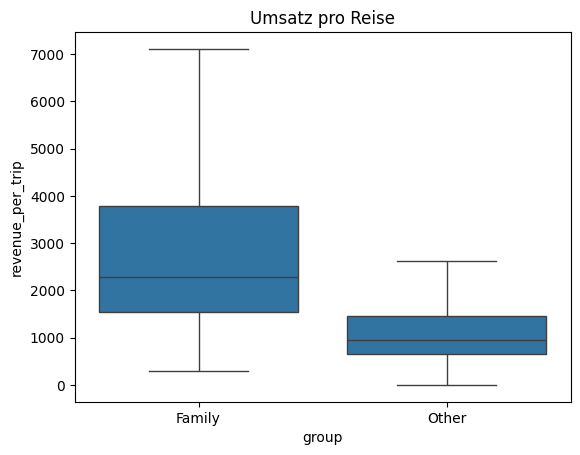

In [100]:
comparison["revenue_per_trip"] = (
    comparison["total_revenue_w_discount"]
    / comparison["amount_total_trips"]
)

sns.boxplot(
    data=comparison,
    x="group",
    y="revenue_per_trip",
    showfliers=False
)

plt.title("Umsatz pro Reise")
plt.show()

Nutzer mit Stornierungen generieren insgesamt geringere Umsätze als Nutzer ohne Stornierungen. Die Analyse des Umsatzes pro Reise zeigt jedoch nur geringe Unterschiede zwischen den Gruppen. Der niedrigere Gesamtumsatz der Stornierer ist daher hauptsächlich auf eine geringere Reiseaktivität zurückzuführen und nicht auf niedrigere Ausgaben pro Reise.

In [101]:
cancel_share = (
    cancellation_group["total_revenue_w_discount"].sum()
    / user_features["total_revenue_w_discount"].sum()
) * 100

cancel_user_share = (
    len(cancellation_group)
    / len(user_features)
) * 100

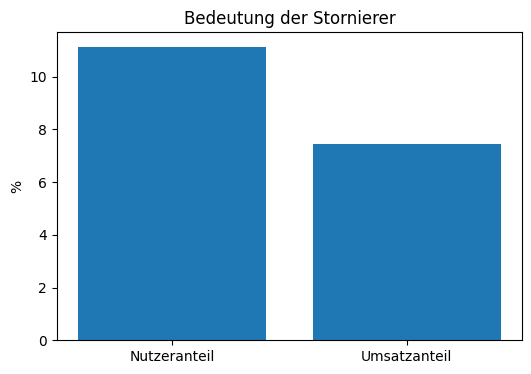

In [102]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Nutzeranteil", "Umsatzanteil"],
    [cancel_user_share, cancel_share]
)

plt.ylabel("%")
plt.title("Bedeutung der Stornierer")

plt.show()

Die Stornierer machen etwa 11 % aller Nutzer aus, generieren aber nur 7,5 % des Gesamtumsatzes.

In [103]:
cancel_revenue = cancellation_group["total_revenue_w_discount"].sum()

other_revenue = user_features[
    ~user_features["user_id"].isin(cancellation_group["user_id"])
]["total_revenue_w_discount"].sum()

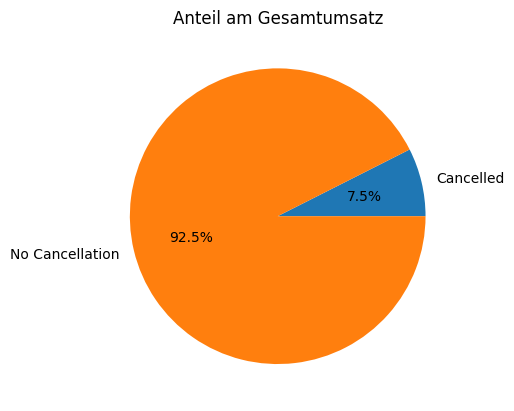

In [104]:
plt.pie(
    [cancel_revenue, other_revenue],
    labels=["Cancelled", "No Cancellation"],
    autopct="%1.1f%%"
)

plt.title("Anteil am Gesamtumsatz")
plt.show()

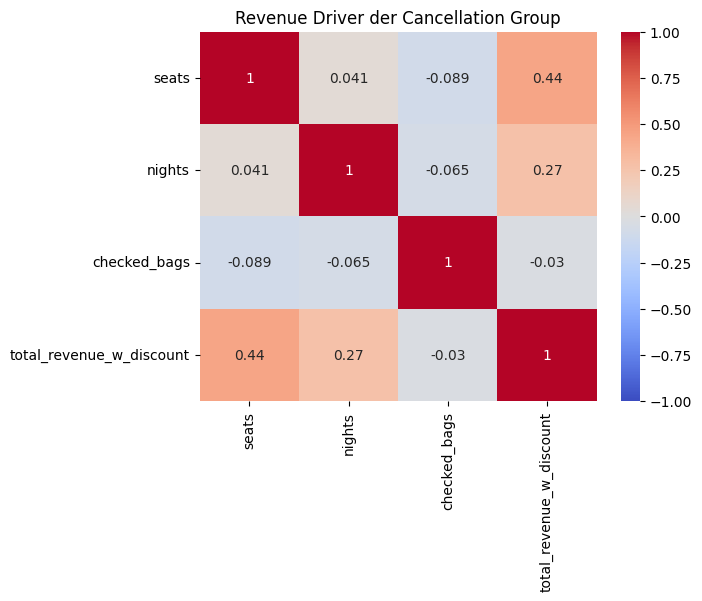

In [105]:
cancel_corr = cancellation_group[
    ["seats","nights","checked_bags","total_revenue_w_discount"]
].corr()

sns.heatmap(
    cancel_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Revenue Driver der Cancellation Group")
plt.show()

Die Korrelationsanalyse der Stornierungsgruppe zeigt, dass die Anzahl der gebuchten Sitzplätze den stärksten Zusammenhang mit dem Umsatz aufweist (r = 0,44). Die Anzahl der Übernachtungen weist einen moderaten positiven Zusammenhang auf (r = 0,27), während aufgegebenes Gepäck praktisch keinen Einfluss auf den Umsatz zeigt (r = −0,03). Der Umsatz stornierender Kunden wird somit vor allem durch die Gruppengröße und die Reisedauer bestimmt.

#Mögliche Business-Empfehlung

Maßnahmen zur Reduzierung von Stornierungen sollten sich insbesondere auf die Erhöhung der Kundenbindung konzentrieren. Da Stornierer grundsätzlich ähnliche Beträge pro Reise ausgeben, besteht Potenzial, diese Nutzer durch flexiblere Umbuchungsoptionen oder personalisierte Angebote zu aktiveren und ihre Reisehäufigkeit zu erhöhen. Mögliche Business-Empfehlung



| Segment      | Nutzeranteil |                   Umsatzanteil | Bewertung             |
| ------------ | -----------: | -----------------------------: | --------------------- |
| Family       |       ~2,6 % |                         ~8,5 % | sehr wertvoll         |
| Cancellation |        ~11 % |                         ~7,5 % | unterdurchschnittlich |
| Business     |       ~4,5 % |             vermutlich moderat | häufige Reisen        |
| Short Trip   |       ~7,5 % | deutlich unterdurchschnittlich | geringe Umsätze       |



In [106]:
user_features = user_features[~user_features["user_id"].isin(cancellation_group["user_id"])].copy()

#Favourite hotel

In [107]:
fav_hotel_group = user_features[user_features["fav_hotel"].notnull()]

In [108]:
fav_hotel_group.shape

(530, 25)

In [109]:
comparison = pd.concat([
    fav_hotel_group.assign(group="Favorite Hotel"),
    user_features[
        ~user_features["user_id"].isin(fav_hotel_group["user_id"])
    ].assign(group="Other")
])

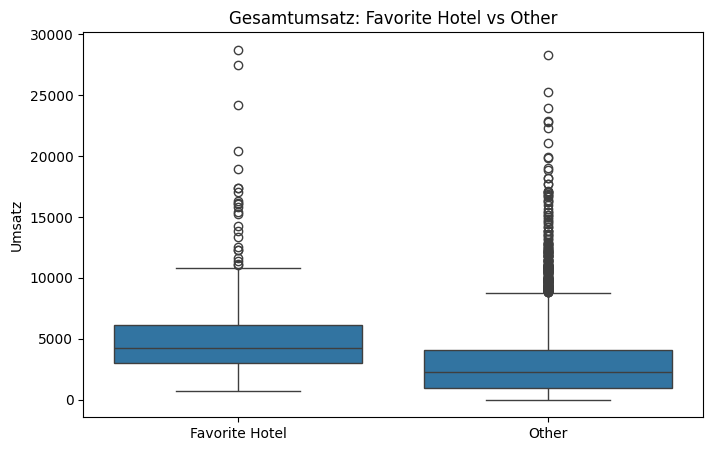

In [110]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=comparison,
    x="group",
    y="total_revenue_w_discount"
)

plt.title("Gesamtumsatz: Favorite Hotel vs Other")
plt.xlabel("")
plt.ylabel("Umsatz")
plt.show()

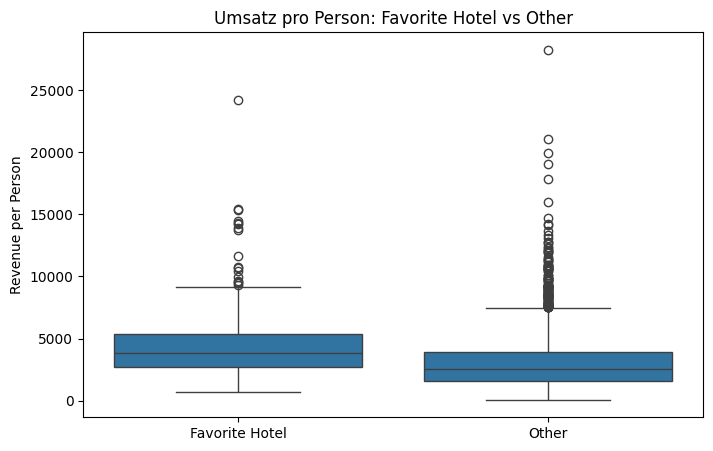

In [111]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=comparison,
    x="group",
    y="revenue_per_person"
)

plt.title("Umsatz pro Person: Favorite Hotel vs Other")
plt.xlabel("")
plt.ylabel("Revenue per Person")
plt.show()

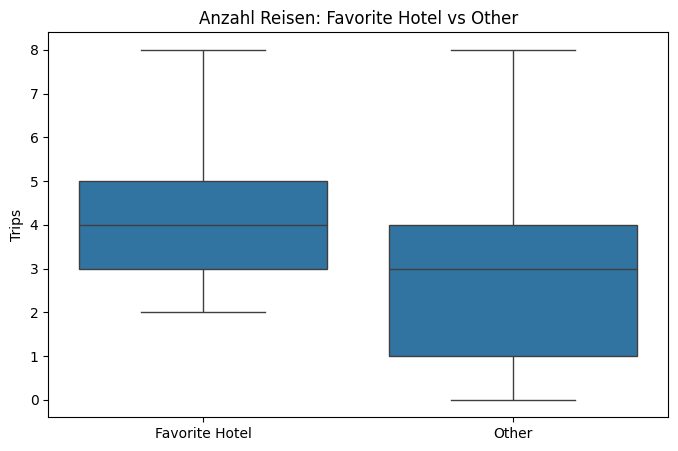

In [112]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=comparison,
    x="group",
    y="amount_total_trips"
)

plt.title("Anzahl Reisen: Favorite Hotel vs Other")
plt.xlabel("")
plt.ylabel("Trips")
plt.show()

In [113]:
metrics = [
    "amount_total_trips",
    "nights",
    "checked_bags",
    "revenue_per_trip",
    "total_revenue_w_discount"
]

comparison.groupby("group")[metrics].mean()

,amount_total_trips,nights,checked_bags,revenue_per_trip,total_revenue_w_discount
group,,,,,
Favorite Hotel,4.183019,3.753576,0.575047,1236.389250,5066.894131
Other,2.472010,4.277803,0.633989,1264.639212,3018.761337


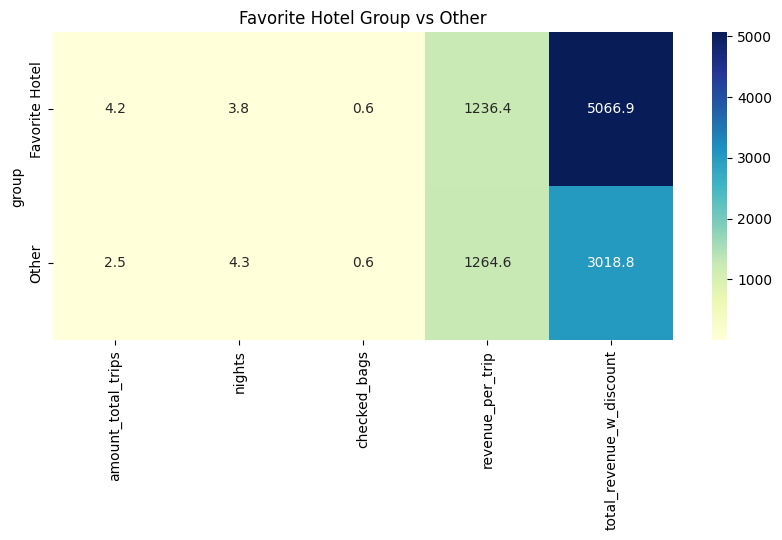

In [114]:
plt.figure(figsize=(10,4))

sns.heatmap(
    comparison.groupby("group")[metrics].mean(),
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Favorite Hotel Group vs Other")
plt.show()

Kunden mit einem bevorzugten Hotel stellen ein wertvolles Stammkundensegment dar. Ihr höherer Umsatz entsteht vor allem durch häufigere Reisen und eine starke Bindung an bestimmte Hotels. Diese Gruppe eignet sich besonders für Bonusprogramme und personalisierte Angebote.

Diese Kunden sind besonders wertvoll, weil:
- sie regelmäßig zurückkehren
- geringe Marketingkosten verursachen
- planbare Umsätze liefern
- gute Kandidaten für Loyalty-Programme sind

#Buisiness Empfehlungen

- Kostenloses Frühstück
- Zimmer-Upgrades
- Treuepunkte und Gratisnächte
- Familienrabatte
- Exklusive Angebote für Stammkunden

In [115]:
user_features = user_features[~user_features["user_id"].isin(fav_hotel_group["user_id"])].copy()

#Solo young group

In [116]:
solo_young_traveler_group = user_features[(user_features['seats'] == 1.0)&(user_features['rooms'] == 1.0) & (user_features['age']<30)]

In [117]:
solo_young_traveler_group.shape

(145, 25)

In [119]:
comparison = pd.concat([
    solo_young_traveler_group.assign(group="Solo Young"),
    user_features.assign(group="Other")
])

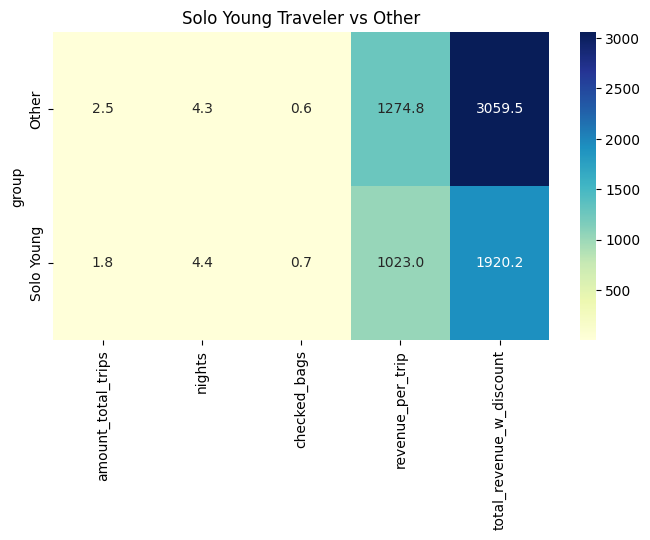

In [120]:
metrics = [
    "amount_total_trips",
    "nights",
    "checked_bags",
    "revenue_per_trip",
    "total_revenue_w_discount"
]

heatmap_data = comparison.groupby("group")[metrics].mean()

plt.figure(figsize=(8,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Solo Young Traveler vs Other")
plt.show()

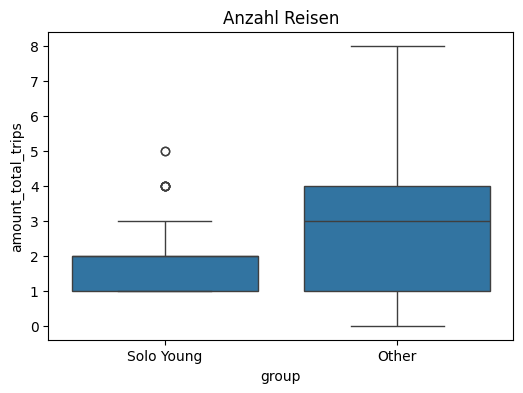

In [121]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="amount_total_trips"
)

plt.title("Anzahl Reisen")
plt.show()

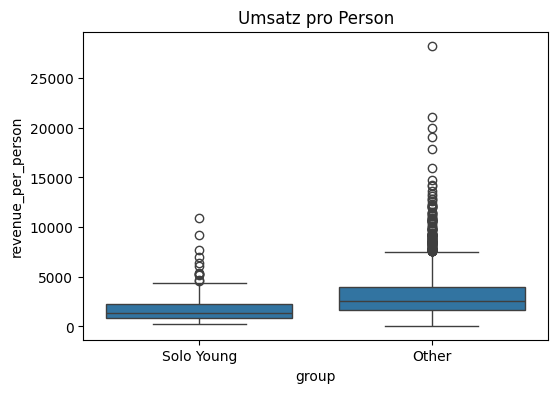

In [122]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="revenue_per_person"
)

plt.title("Umsatz pro Person")
plt.show()

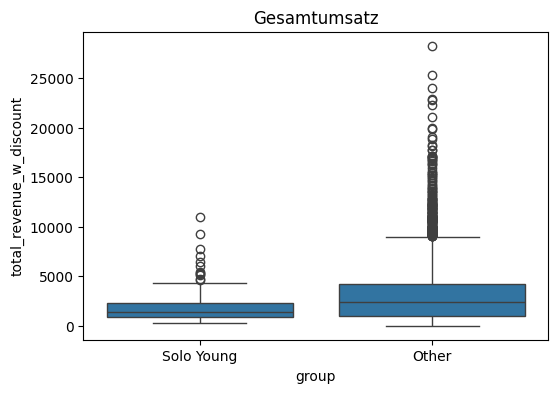

In [123]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="total_revenue_w_discount"
)

plt.title("Gesamtumsatz")
plt.show()

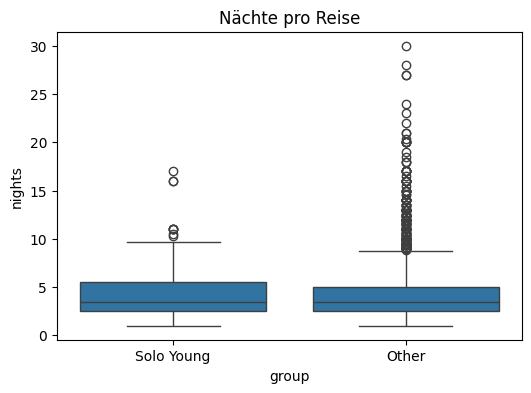

In [124]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="nights"
)

plt.title("Nächte pro Reise")
plt.show()

Die Solo Young Traveler reisen allein und sind jünger als 30 Jahre. Sie reisen seltener und generieren geringere Umsätze als andere Kundengruppen. Da sie jedoch eine wichtige zukünftige Zielgruppe darstellen, eignen sich insbesondere preisorientierte Angebote, flexible Buchungsoptionen und Treueprogramme zur langfristigen Kundenbindung.

#Mögliche Business Ideen

- Preisvorteile, Rabattcodes
- Studentenrabatte
- Last-Minute-Angebote
- Flexibilität(Flexible Stornierung)
- Kostenlose Umbuchung
- Mobile Check-in
- Erlebnisangebote, Event-Tickets, Stadtführungen, Freizeit- und Nightlife-Angebote, Aktivitäten vor Ort
- Bonuspunkte, Empfehlungsbonus für Freunde
- Rabatt auf die nächste Reise


In [118]:
user_features = user_features[~user_features["user_id"].isin(solo_young_traveler_group["user_id"])].copy()

#Seniors

In [125]:
seniors_group = user_features.query("age>=60")

In [126]:
seniors_group.shape

(359, 25)

In [130]:
comparison = pd.concat([
    seniors_group.assign(group="Seniors"),
    user_features.assign(group="Other")
])

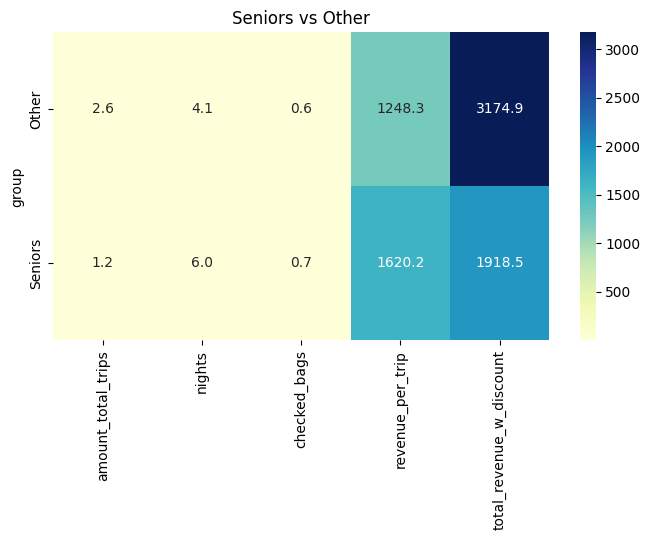

In [131]:
metrics = [
    "amount_total_trips",
    "nights",
    "checked_bags",
    "revenue_per_trip",
    "total_revenue_w_discount"
]

heatmap_data = comparison.groupby("group")[metrics].mean()

plt.figure(figsize=(8,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Seniors vs Other")
plt.show()

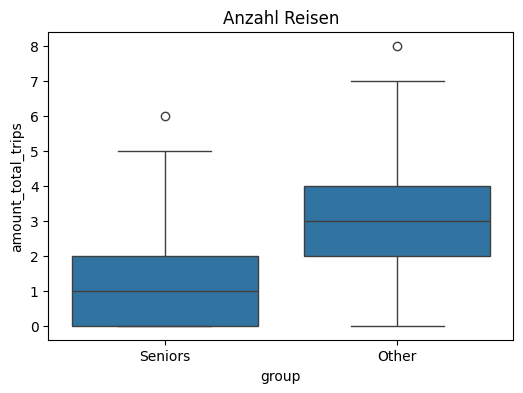

In [132]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="amount_total_trips"
)

plt.title("Anzahl Reisen")
plt.show()

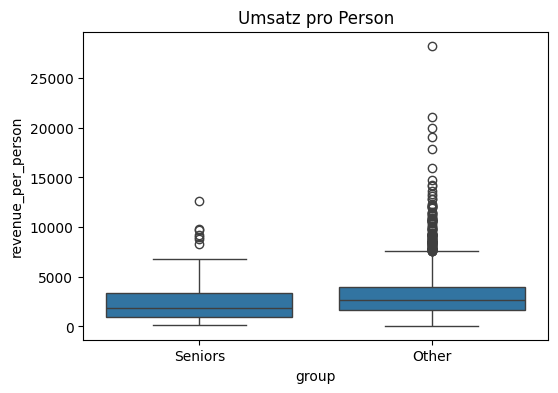

In [133]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="revenue_per_person"
)

plt.title("Umsatz pro Person")
plt.show()

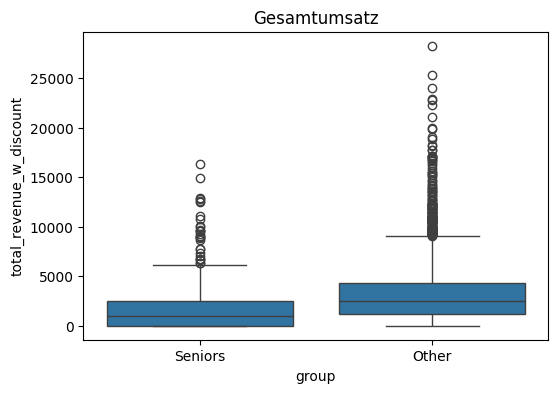

In [134]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="total_revenue_w_discount"
)

plt.title("Gesamtumsatz")
plt.show()

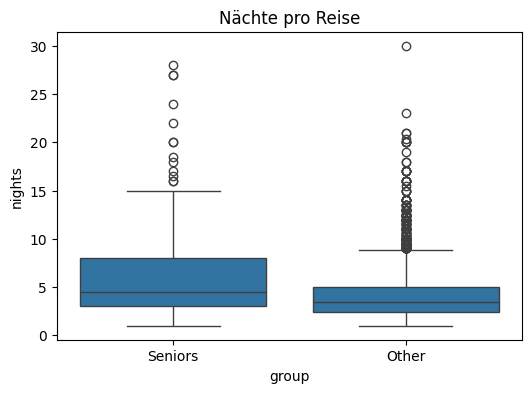

In [135]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="nights"
)

plt.title("Nächte pro Reise")
plt.show()

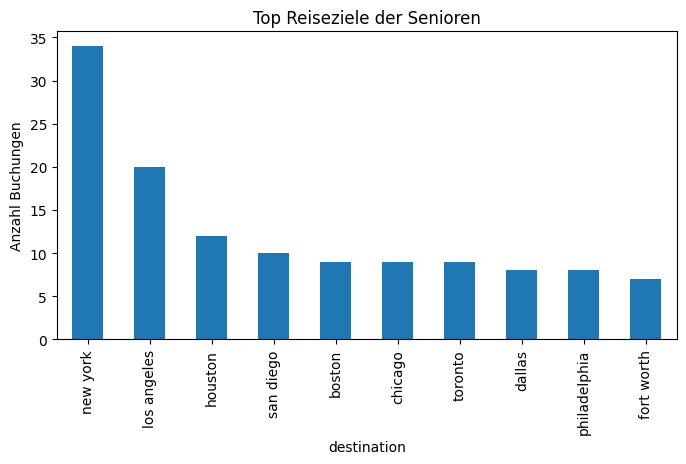

In [136]:
senior_destinations = flights[
    flights["user_id"].isin(seniors_group["user_id"])
]["destination"].value_counts().head(10)

senior_destinations.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top Reiseziele der Senioren")
plt.ylabel("Anzahl Buchungen")
plt.show()

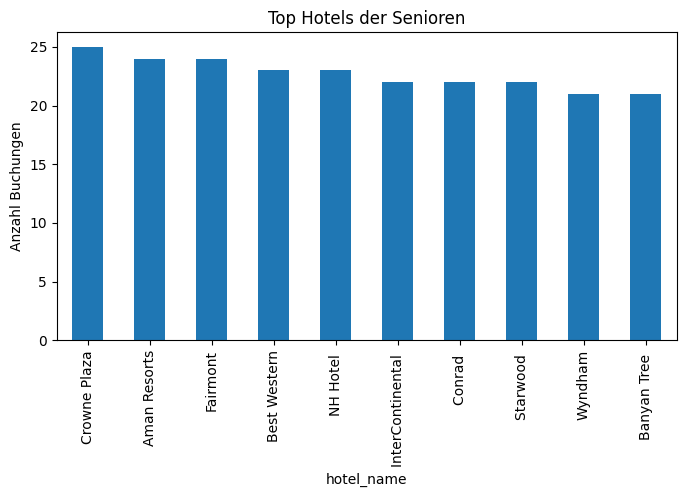

In [137]:
senior_hotels = hotels[
    hotels["user_id"].isin(seniors_group["user_id"])
]["hotel_name"].value_counts().head(10)

senior_hotels.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Top Hotels der Senioren")
plt.ylabel("Anzahl Buchungen")
plt.show()

Die Seniors Group (Nutzer ab 60 Jahren) reist deutlich seltener als andere Kunden, verbringt jedoch mehr Nächte pro Reise. Mit durchschnittlich 6 Nächten pro Aufenthalt bleiben Senioren fast zwei Nächte länger als die Vergleichsgruppe. Dadurch erzielen sie einen höheren Umsatz pro Reise, obwohl ihr Gesamtumsatz aufgrund der geringeren Reisehäufigkeit niedriger ausfällt.

Bei den Reisezielen bevorzugen Senioren vor allem große Städte wie New York, Los Angeles und Houston. Bei der Hotelauswahl zeigen sie eine klare Präferenz für bekannte und etablierte Hotelketten wie Crowne Plaza, Fairmont oder InterContinental, was auf ein stärkeres Bedürfnis nach Komfort, Sicherheit und Verlässlichkeit hindeutet.

# Empfohlene Perks

- Frühstück inklusive
- Zimmer-Upgrades
- Wellness-Angebote
- Flughafentransfer
- Treueprogramm

In [127]:
user_features = user_features[~user_features["user_id"].isin(seniors_group["user_id"])].copy()

#No bookers

In [128]:
no_booker_group = user_features.query("amount_total_trips == 0")

In [129]:
no_booker_group.shape

(343, 25)

In [139]:
comparison = pd.concat([
    no_booker_group.assign(group="No Booker"),
    user_features.assign(group="Other")
])

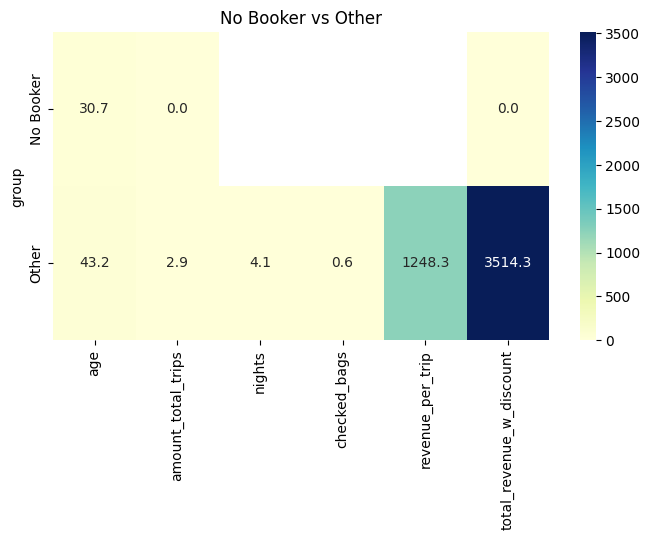

In [140]:
metrics = [
    "age",
    "amount_total_trips",
    "nights",
    "checked_bags",
    "revenue_per_trip",
    "total_revenue_w_discount"
]

heatmap_data = comparison.groupby("group")[metrics].mean()

plt.figure(figsize=(8,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("No Booker vs Other")
plt.show()

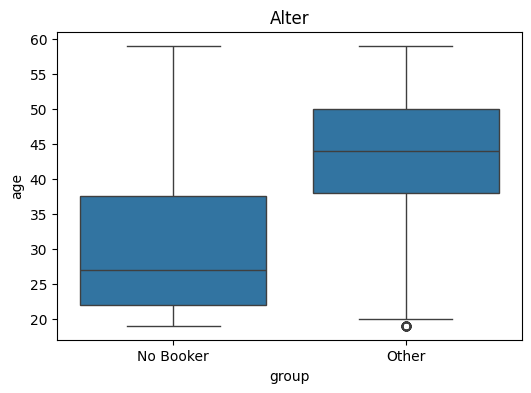

In [141]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="age"
)

plt.title("Alter")
plt.show()

##Die No Booker Group besteht aus jüngeren Nutzern (Ø 31 Jahre), die sich registriert haben, aber bisher keine Reise gebucht haben. Sie generieren aktuell keinen Umsatz, stellen jedoch ein wichtiges Wachstumspotenzial dar. Durch gezielte Einstiegsangebote, Rabatte und personalisierte Empfehlungen können diese Nutzer in aktive Kunden umgewandelt werden.

In [144]:
user_features = user_features[~user_features["user_id"].isin(no_booker_group["user_id"])].copy()

#High hotel spenders

In [145]:
user_features["hotel_revenue_per_trip"] = user_features["hotel_revenue_w_discount"] /user_features["amount_total_trips"]/user_features["rooms"]/user_features["nights"]

In [146]:
high_hotel_spenders = user_features.query('hotel_revenue_per_trip > 250')

In [147]:
high_hotel_spenders.shape

(392, 26)

In [148]:
comparison = pd.concat([
    high_hotel_spenders.assign(group="High Hotel Spender"),
    user_features.assign(group="Other")
])

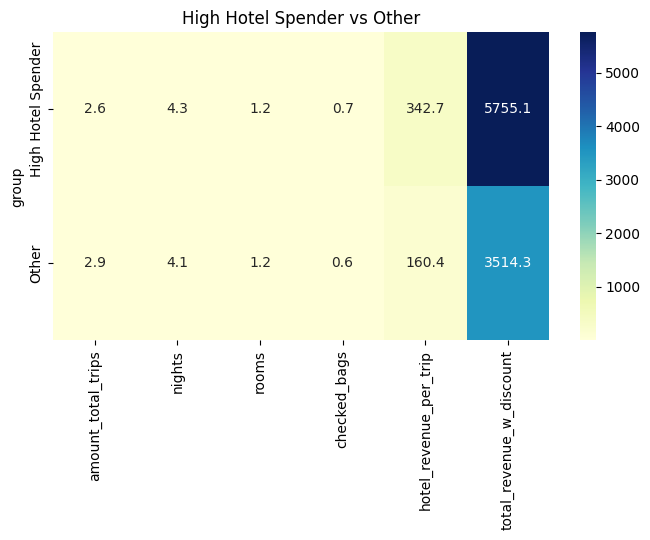

In [149]:
metrics = [
    "amount_total_trips",
    "nights",
    "rooms",
    "checked_bags",
    "hotel_revenue_per_trip",
    "total_revenue_w_discount"
]

heatmap_data = comparison.groupby("group")[metrics].mean()

plt.figure(figsize=(8,4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("High Hotel Spender vs Other")
plt.show()

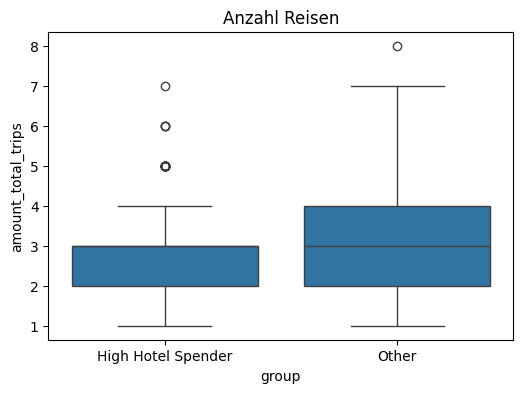

In [150]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="amount_total_trips"
)

plt.title("Anzahl Reisen")
plt.show()

In [159]:
comparison = pd.concat([
    high_hotel_spenders.assign(group="High Hotel Spender"),
    user_features.assign(group="Other")
], ignore_index=True)

comparison = comparison.reset_index(drop=True)

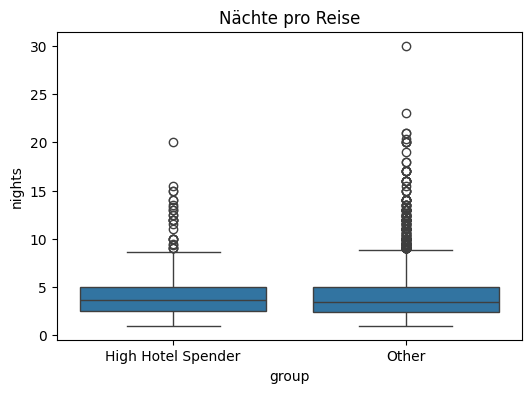

In [160]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="nights"
)

plt.title("Nächte pro Reise")
plt.show()

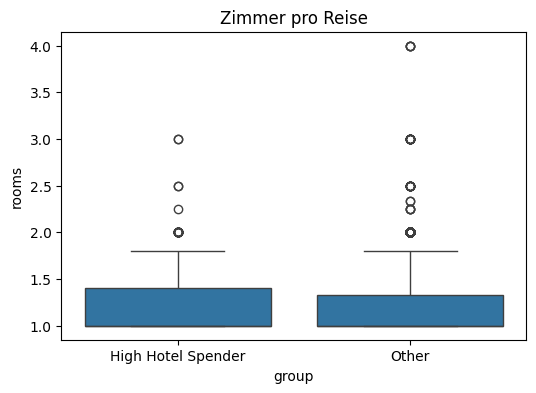

In [161]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="rooms"
)

plt.title("Zimmer pro Reise")
plt.show()

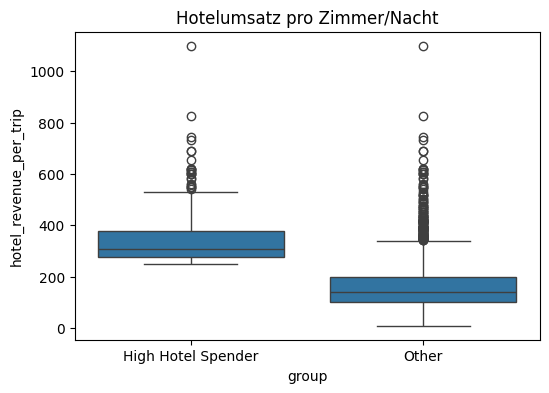

In [162]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="hotel_revenue_per_trip"
)

plt.title("Hotelumsatz pro Zimmer/Nacht")
plt.show()

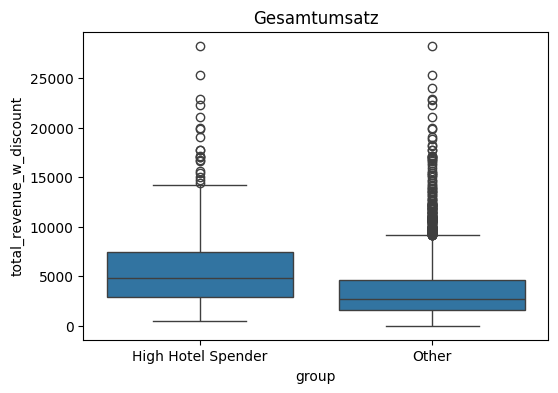

In [163]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="total_revenue_w_discount"
)

plt.title("Gesamtumsatz")
plt.show()

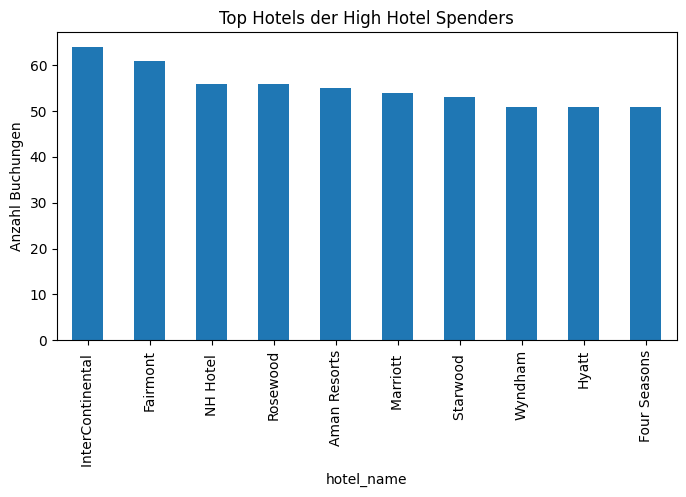

In [164]:
top_hotels = hotels[
    hotels["user_id"].isin(high_hotel_spenders["user_id"])
]["hotel_name"].value_counts().head(10)

plt.figure(figsize=(8,4))

top_hotels.plot(kind="bar")

plt.title("Top Hotels der High Hotel Spenders")
plt.ylabel("Anzahl Buchungen")
plt.show()

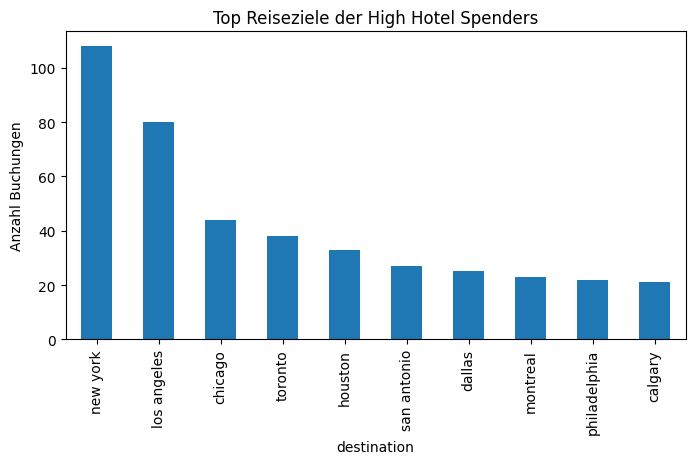

In [165]:
top_destinations = flights[
    flights["user_id"].isin(high_hotel_spenders["user_id"])
]["destination"].value_counts().head(10)

plt.figure(figsize=(8,4))

top_destinations.plot(kind="bar")

plt.title("Top Reiseziele der High Hotel Spenders")
plt.ylabel("Anzahl Buchungen")
plt.show()

Die High Hotel Spenders generieren den höchsten Hotel- und Gesamtumsatz aller Kundensegmente. Sie reisen nicht häufiger als andere Kunden, buchen jedoch deutlich hochwertigere Hotels. Die Gruppe bevorzugt bekannte Premium-Hotelketten und eignet sich besonders für exklusive Serviceangebote, VIP-Programme und Upselling-Maßnahmen.

#Geeignete Perks
- Zimmer-Upgrades
- VIP-Status
- Lounge-Zugang
- Kostenloses Frühstück
- Spa- und Wellness-Angebote
- Late Check-out
- Concierge-Service
- Exklusive Hotelpartnerschaften
- Premium-Treueprogramm

In [166]:
user_features = user_features[~user_features["user_id"].isin(high_hotel_spenders["user_id"])].copy()

#Overcarrier

In [167]:
over_carrier_group = user_features.query("checked_bags > 1")

In [168]:
over_carrier_group.shape

(134, 26)

In [172]:
comparison = pd.concat([
    over_carrier_group.assign(group="Overcarrier"),
    user_features.assign(group="Other")
], ignore_index=True)

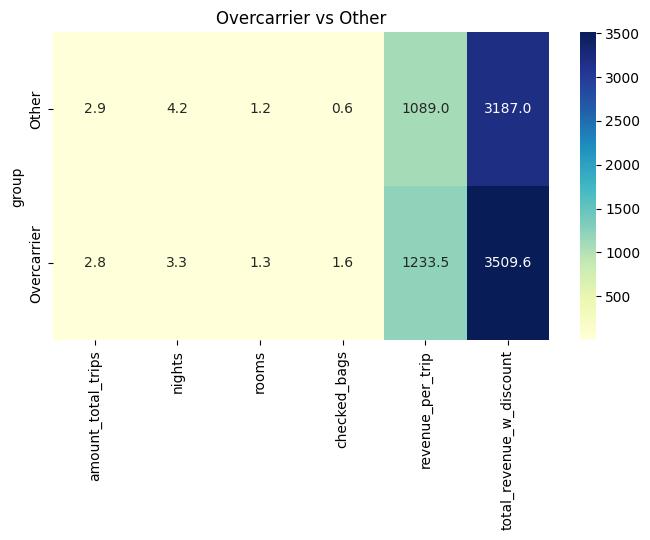

In [173]:
heatmap_data = comparison.groupby("group")[
    [
        "amount_total_trips",
        "nights",
        "rooms",
        "checked_bags",
        "revenue_per_trip",
        "total_revenue_w_discount"
    ]
].mean()

plt.figure(figsize=(8,4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Overcarrier vs Other")
plt.show()

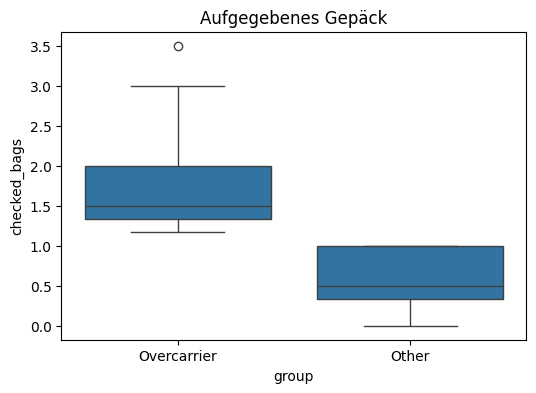

In [174]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="checked_bags"
)

plt.title("Aufgegebenes Gepäck")
plt.show()

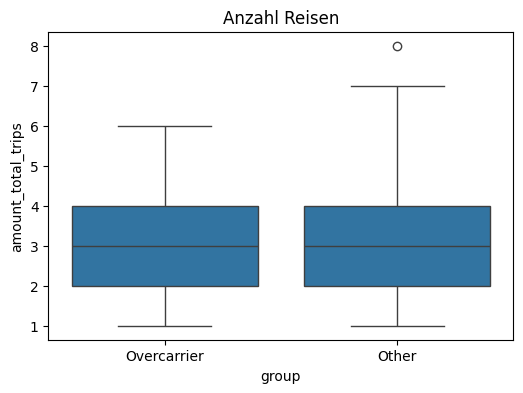

In [175]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="amount_total_trips"
)

plt.title("Anzahl Reisen")
plt.show()

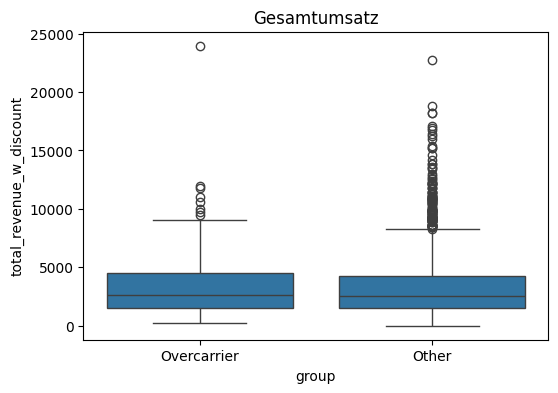

In [176]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="total_revenue_w_discount"
)

plt.title("Gesamtumsatz")
plt.show()

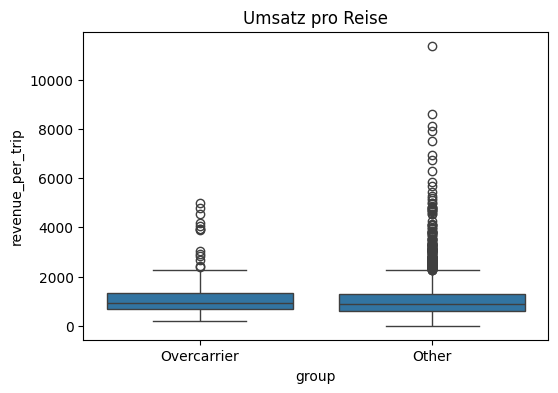

In [177]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=comparison,
    x="group",
    y="revenue_per_trip"
)

plt.title("Umsatz pro Reise")
plt.show()

Die Overcarrier-Gruppe reist ähnlich häufig wie andere Kunden, transportiert jedoch deutlich mehr Gepäck und erzielt höhere Umsätze pro Reise. Dies deutet auf Familien-, Urlaubs- oder Langstreckenreisen hin. Besonders attraktiv sind Services rund um Gepäck, Komfort und Familienreisen.

#Mögliche Perks
- Kostenloses Zusatzgepäck
- Priority Baggage Handling
- Familienpakete
- Rabatte auf weiteres Gepäck
- Flughafentransfer
- Early Check-in / Late Check-out
- Lounge-Zugang für Familien
- Reiseversicherung inklusive Gepäckschutz

In [169]:
user_features = user_features[~user_features["user_id"].isin(over_carrier_group["user_id"])].copy()

#Rest Group

In [170]:
user_features.to_csv("/content/drive/MyDrive/rest_group.csv", index=False)

In [171]:
user_features.shape

(2682, 26)

In [184]:
segments = {
    "Family": family_traveler_group,
    "Seniors": seniors_group,
    "Solo Young": solo_young_traveler_group,
    "Overcarrier": over_carrier_group,
    "High Hotel": high_hotel_spenders,
    "Favorite Hotel": fav_hotel_group,
    "Business": business_group,
    "Short Trip": short_trip_group
}

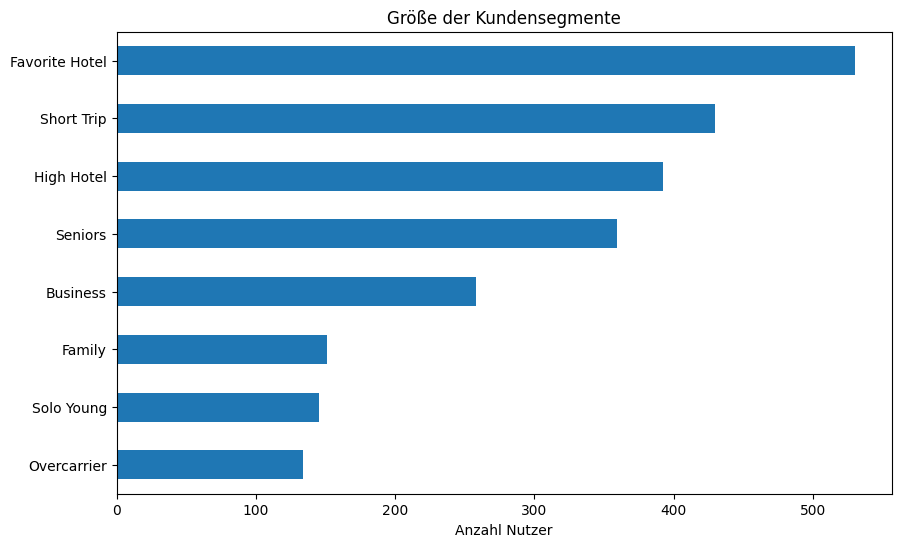

In [185]:
segment_sizes = {
    name: len(grp)
    for name, grp in segments.items()
}

pd.Series(segment_sizes).sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Anzahl Nutzer")
plt.title("Größe der Kundensegmente")
plt.show()